CNN ALGORITHM FOR TUBERCLOSIS EARLY DETECTION

IMPORT:

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import os
from google.colab import drive
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input as enet_preprocess

MOUNTING GOOGLE DRIVE:

In [ ]:
print("Mounting Google Drive...")
drive.mount('/content/drive')
DATA_DIR = "/content/drive/My Drive/TB_DATASET"

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


MODEL PARAMETERS:

In [ ]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
EPOCHS = 15

LOAD RAW DATA ONCE:

In [ ]:
if not os.path.isdir(DATA_DIR):
    print(f"\nERROR: Data directory not found at {DATA_DIR}")
    print("Please check: 1. Google Drive is mounted. 2. DATA_DIR path is CORRECT.")
    exit()

print("\nLoading raw datasets...")

raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=1337,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

raw_val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=1337,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

class_names = raw_train_ds.class_names
print(f"Found classes: {class_names}")


Loading raw datasets...
Found 4200 files belonging to 2 classes.
Using 3360 files for training.
Found 4200 files belonging to 2 classes.
Using 840 files for validation.
Found classes: ['Normal', 'Tuberculosis']


DATA AUGMENTATION:

In [ ]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ],
    name="data_augmentation",
)

THE HELPER FUNCTIONS:

In [ ]:
def create_preprocessed_dataset(dataset, preprocess_function, augment=False):
    """Applies model-specific preprocessing and augmentation."""
    ds = dataset.map(lambda x, y: (preprocess_function(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
def create_model(input_shape):
    """Creates and freezes the EfficientNetB3 transfer learning model."""
    base_model = EfficientNetB3(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    # Freeze the base model for feature extraction
    base_model.trainable = False

    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    # Add a Batch Normalization layer for stability, which is common in ENet heads
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x) # A slightly higher dropout for ENet
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name="EfficientNetB3_Classifier")

    # Use a slightly lower learning rate Adam optimizer often helps stabilize ENet training
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),loss='binary_crossentropy', metrics=['accuracy']
    )
    return model

def evaluate_model(model, val_ds, class_names, title, history=None):
    """Runs evaluation metrics, plots CM, and plots history."""

    # Get true labels from the raw validation dataset
    y_true_list = []
    for images, labels in raw_val_ds.unbatch().as_numpy_iterator():
        y_true_list.append(labels)
    y_true = np.array(y_true_list).flatten()

    # Get predictions
    print("\nPredicting on validation data...")
    y_probs = model.predict(val_ds).flatten()
    y_pred = (y_probs > 0.5).astype(int)

    # Metrics
    accuracy = accuracy_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_probs)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n--- {title} Performance ---")
    print(f"Overall Accuracy: {accuracy * 100:.2f}%")
    print(f"ROC-AUC Score: {roc_auc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    print("Confusion Matrix:")
    print(cm)

    # Visualize Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{title} Confusion Matrix\nAccuracy: {accuracy*100:.2f}%')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # Plot Training History
    if history:
        acc = history.history['accuracy']
        val_acc = history.history['val_accuracy']
        loss = history.history['loss']
        val_loss = history.history['val_loss']

        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(acc, label='Training Accuracy')
        plt.plot(val_acc, label='Validation Accuracy')
        plt.legend(loc='lower right')
        plt.title(f'{title} - Training and Validation Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.subplot(1, 2, 2)
        plt.plot(loss, label='Training Loss')
        plt.plot(val_loss, label='Validation Loss')
        plt.legend(loc='upper right')
        plt.title(f'{title} - Training and Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.suptitle(f'{title} Model Training History')
        plt.show()
    return accuracy, roc_auc

EfficientNet83 MODEL TRAINING AND EVALUATION:

SECTION A: EfficientNetB3 Model (Highest Accuracy CNN)

EfficientNetB3 Model Summary:


Model: "EfficientNetB3_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,177,264 (42.64 MB)

 Trainable params: 393,729 (1.50 MB)

 Non-trainable params: 10,783,535 (41.14 MB)


--- Starting EfficientNetB3 Training ---
Epoch 1/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 134s 790ms/step - accuracy: 0.7872 - loss: 0.4362 - val_accuracy: 0.9012 - val_loss: 0.2613
Epoch 2/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.9186 - loss: 0.2078 - val_accuracy: 0.9083 - val_loss: 0.2226
Epoch 3/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - accuracy: 0.9376 - loss: 0.1673 - val_accuracy: 0.9202 - val_loss: 0.1962
Epoch 4/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - accuracy: 0.9473 - loss: 0.1442 - val_accuracy: 0.9262 - val_loss: 0.1750
Epoch 5/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.9599 - loss: 0.1182 - val_accuracy: 0.9333 - val_loss: 0.1680
Epoch 6/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - accuracy: 0.9600 - loss: 0.1096 - val_accuracy: 0.9369 - val_loss: 0.1668
Epoch 7/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.9655 - loss: 0.1023 - val_accuracy: 0.9429 - val_loss: 0.1479
Epoch 8/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step

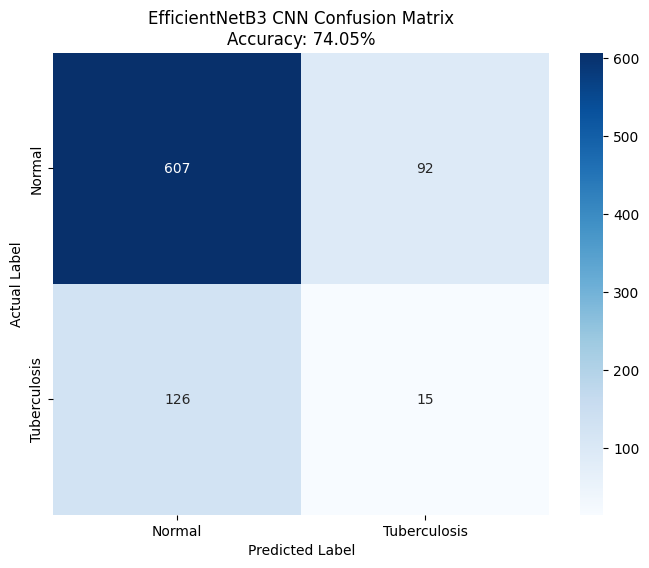

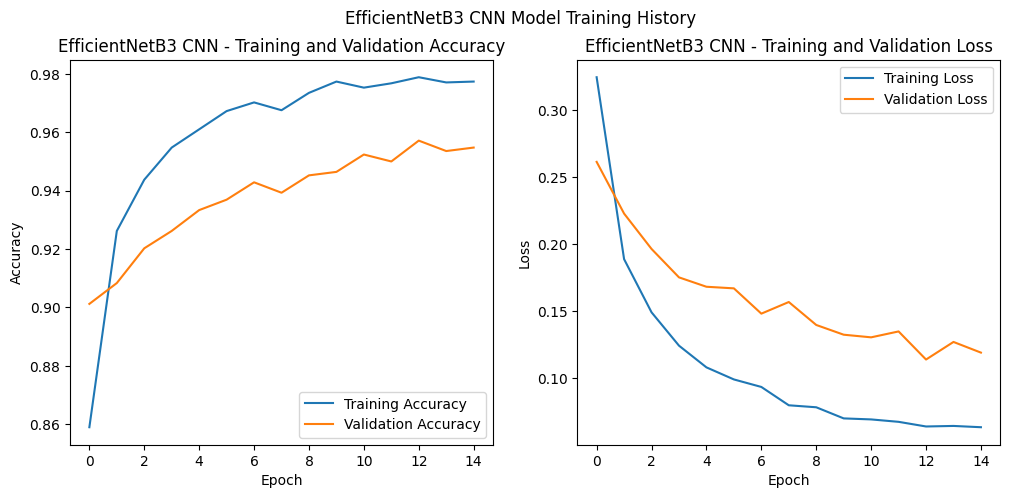

In [ ]:
print("SECTION A: EfficientNetB3 Model (Highest Accuracy CNN)")
#1. Create specific datasets for EfficientNetB3
enet_train_ds = create_preprocessed_dataset(raw_train_ds, enet_preprocess, augment=True)
enet_val_ds = create_preprocessed_dataset(raw_val_ds, enet_preprocess, augment=False)
# 2. Create and Train the EfficientNetB3 model
enet_model = create_model(IMAGE_SIZE + (3,))
print("\nEfficientNetB3 Model Summary:")
enet_model.summary()
#The training
print("\n--- Starting EfficientNetB3 Training ---")
enet_history = enet_model.fit(
    enet_train_ds,
    epochs=EPOCHS,
    validation_data=enet_val_ds,
    # Add an early stopping callback to prevent overfitting and save time
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
)
print("--- EfficientNetB3 Training Finished ---")

# 3. Evaluation of the Model
enet_acc, enet_auc = evaluate_model(enet_model, enet_val_ds, class_names, "EfficientNetB3 CNN", history=enet_history)


MODEL SAVING ON THE GOOGLE DRIVE:

In [ ]:
print("SECTION B: Saving Model to Google Drive")
MODEL_SAVE_DIR = os.path.join("/content/drive/My Drive/PROJECTS", "Tuberculosis_Trained_EfficientNet")
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
# Save the model weights using the required '.weights.h5' extension
save_path = os.path.join(MODEL_SAVE_DIR, 'EfficientNetB3_weights.weights.h5')
enet_model.save_weights(save_path)
print(f"Saved EfficientNetB3 weights to: {save_path}")

SECTION B: Saving Model to Google Drive
Saved EfficientNetB3 weights to: /content/drive/My Drive/PROJECTS/Tuberculosis_Trained_EfficientNet/EfficientNetB3_weights.weights.h5


THE FINAL PERFORMANCE SUMMARY:

In [ ]:
print("  FINAL PERFORMANCE SUMMARY: EfficientNetB3 CNN")
print(f"1. EfficientNetB3 Accuracy: {enet_acc * 100:.2f}%")
print(f"   EfficientNetB3 ROC-AUC: {enet_auc:.4f}")
print("\n--- Process Finished. Weights are saved in your Google Drive. ---")

  FINAL PERFORMANCE SUMMARY: EfficientNetB3 CNN
1. EfficientNetB3 Accuracy: 74.05%
   EfficientNetB3 ROC-AUC: 0.4745

--- Process Finished. Weights are saved in your Google Drive. ---


THE TESTING OF THIS ALGORITHM FOR PREDICTING THE X-RAY IMAGE:

In [ ]:
import os
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image as keras_image
# Assuming you are using EfficientNet based on 'enet_preprocess'
from tensorflow.keras.applications.efficientnet import preprocess_input as enet_preprocess

# --- 1. DEFINE THE MISSING LABELS HERE ---
# based on your code logic: 0 = Normal, 1 = Tuberculosis
CLASS_LABELS = ['Normal', 'Tuberculosis']

def predict_single_image(model, image_size, labels):
    """Handles image upload, preprocessing, and prediction for a single image."""

    # 1. Prompt user to upload a file
    print("\n--- Please upload a single chest X-ray image for prediction: ---")

    # Use a try/except block specific for the upload process
    try:
        uploaded = files.upload()
    except Exception as e:
        print(f"Error during file upload utility: {e}")
        print("Please ensure you are running this in a Colab notebook.")
        return

    if not uploaded:
        print("No file uploaded. Skipping single image prediction.")
        return

    # Get the name of the uploaded file
    file_name = next(iter(uploaded))

    try:
        # 2. Load and preprocess the image
        img = keras_image.load_img(file_name, target_size=image_size)
        img_array = keras_image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)

        # Apply the same preprocessing used during training (EfficientNet specific)
        processed_img = enet_preprocess(img_array)

        # 3. Predict
        prediction_prob = model.predict(processed_img)[0][0]

        # Determine the class (0=normal, 1=tuberculosis)
        if prediction_prob >= 0.5:
            predicted_class_index = 1
            confidence_score = prediction_prob
        else:
            predicted_class_index = 0
            confidence_score = 1.0 - prediction_prob

        predicted_label = labels[predicted_class_index]

        # 4. Display Result
        print(f"🚀 Prediction for: {file_name}")
        print(f"Diagnosis: **{predicted_label.upper()}**")
        print(f"Confidence: {confidence_score * 100:.2f}%")

    except Exception as e:
        print(f"\nERROR during prediction for {file_name}: {e}")
        print("Please ensure the uploaded file is a valid image in common format (jpg/png).")

    finally:
        # Clean up the uploaded file from the Colab session
        if os.path.exists(file_name):
            os.remove(file_name)

print("FINAL Image Prediction")

# --- CRITICAL CHECK ---
# Ensure 'enet_model' and 'IMAGE_SIZE' are actually in your memory.
# If you restarted the runtime, you must re-run the cells where you trained/loaded the model.
try:
    predict_single_image(enet_model, IMAGE_SIZE, CLASS_LABELS)
    print("\n--- Full Process Finished. ---")
except NameError as e:
    print(f"\nCritical Error: {e}")
    print("It looks like 'enet_model' or 'IMAGE_SIZE' is missing. Please run your training/loading cells first.")

FINAL Image Prediction

--- Please upload a single chest X-ray image for prediction: ---


Saving Tuberculosis-299.png to Tuberculosis-299.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step
🚀 Prediction for: Tuberculosis-299.png
Diagnosis: **TUBERCULOSIS**
Confidence: 99.98%

--- Full Process Finished. ---


ENSEMBLE ALGORITHM FOR THE TUBERCLOSIS EARLY DETECTION

IMPORT:

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from google.colab import files
from tensorflow.keras.preprocessing import image as keras_image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import os
from google.colab import drive
#Importing Ensemble Models and their Preprocessing Functions
from tensorflow.keras.applications import (
    MobileNetV2,
    DenseNet121,
    ResNet50V2
)
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as dnet_preprocess
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess

MOUNTING GOOGLE DRIVE AND COLAB CONFIGURATION FOR THE DATASET:

In [ ]:
print("Mounting Google Drive...")
drive.mount('/content/drive')
DATA_DIR = "/content/drive/My Drive/TB_DATASET"

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


MODEL PARAMETERS:

In [ ]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
EPOCHS = 10

LOAD OF THE RAW DATA:

In [ ]:
if not os.path.isdir(DATA_DIR):
    print(f"\nERROR: Data directory not found at {DATA_DIR}")
    print("Please check: 1. Google Drive is mounted. 2. DATA_DIR path is CORRECT.")
    exit()
print("\nLoading raw datasets...")
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,validation_split=VALIDATION_SPLIT,subset="training",seed=1337,image_size=IMAGE_SIZE,batch_size=BATCH_SIZE,label_mode='binary'
)
raw_val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,validation_split=VALIDATION_SPLIT,subset="validation",seed=1337,image_size=IMAGE_SIZE,batch_size=BATCH_SIZE,label_mode='binary'
)
class_names = raw_train_ds.class_names
print(f"Found classes: {class_names}")


Loading raw datasets...
Found 4200 files belonging to 2 classes.
Using 3360 files for training.
Found 4200 files belonging to 2 classes.
Using 840 files for validation.
Found classes: ['Normal', 'Tuberculosis']


DATA AUGMENTATION:

In [ ]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ],
    name="data_augmentation",
)

THE HELPER FUNCTIONS:

In [ ]:
def create_preprocessed_dataset(dataset, preprocess_function, augment=False):
    """Applies model-specific preprocessing and augmentation."""
    ds = dataset.map(lambda x, y: (preprocess_function(x), y),
                     num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    return ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

def create_model(base_model_class, name, input_shape):
    """Creates and freezes a transfer learning model with a new classification head."""
    base_model = base_model_class(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    # This is Feature Extraction: Freezing the large pre-trained model
    base_model.trainable = False
    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = Model(inputs, outputs, name=name)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

def evaluate_and_plot_individual(model, val_ds, class_names, title, history=None):
    """Evaluates individual model performance and plots training history."""
    # Get true labels (for evaluation)
    y_true_list = []
    for images, labels in raw_val_ds.unbatch().as_numpy_iterator():
        y_true_list.append(labels)
    y_true = np.array(y_true_list).flatten()
    y_probs = model.predict(val_ds).flatten()
    accuracy = accuracy_score(y_true, (y_probs > 0.5).astype(int))
    # Plot training history
    if history:
        print(f"\n--- Training Finished for {title} (Validation Accuracy: {accuracy * 100:.2f}%) ---")
        acc = history.history['accuracy']
        val_acc = history.history['val_accuracy']
        loss = history.history['loss']
        val_loss = history.history['val_loss']

        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(acc, label='Training Accuracy')
        plt.plot(val_acc, label='Validation Accuracy')
        plt.title(f'{title} - Training and Validation Accuracy')
        plt.subplot(1, 2, 2)
        plt.plot(loss, label='Training Loss')
        plt.plot(val_loss, label='Validation Loss')
        plt.title(f'{title} - Training and Validation Loss')
        plt.show()

THE TRAINING OF THE ENSEMBLE MODEL:

SECTION A: Training Individual Models for Ensemble

--- MobileNetV2 ---
MobileNetV2 Model Summary:


Model: "MobileNetV2_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Starting MobileNetV2 Training...
Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 94s 679ms/step - accuracy: 0.9050 - loss: 0.2557 - val_accuracy: 0.9345 - val_loss: 0.1590
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9661 - loss: 0.1056 - val_accuracy: 0.9429 - val_loss: 0.1477
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.9760 - loss: 0.0777 - val_accuracy: 0.9369 - val_loss: 0.1759
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.9834 - loss: 0.0516 - val_accuracy: 0.9369 - val_loss: 0.1905
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.9859 - loss: 0.0509 - val_accuracy: 0.9500 - val_loss: 0.1610
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 224ms/step

--- Training Finished for MobileNetV2 CNN (Validation Accuracy: 75.24%) ---


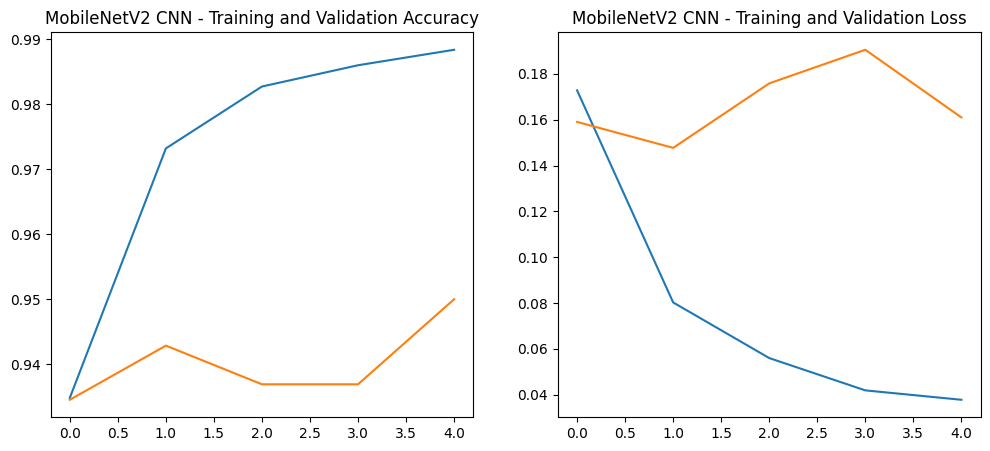


--- DenseNet121 ---
DenseNet121 Model Summary:


Model: "DenseNet121_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,168,833 (27.35 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

Starting DenseNet121 Training...
Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 112s 797ms/step - accuracy: 0.8708 - loss: 0.3259 - val_accuracy: 0.9369 - val_loss: 0.1436
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.9525 - loss: 0.1229 - val_accuracy: 0.9560 - val_loss: 0.1063
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.9660 - loss: 0.0895 - val_accuracy: 0.9631 - val_loss: 0.0852
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.9689 - loss: 0.0749 - val_accuracy: 0.9738 - val_loss: 0.0659
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.9805 - loss: 0.0599 - val_accuracy: 0.9810 - val_loss: 0.0593
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.9783 - loss: 0.0563 - val_accuracy: 0.9833 - val_loss: 0.0512
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.9861 - loss: 0.0444 - val_accuracy: 0.9845 - val_loss: 0.0463
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step -

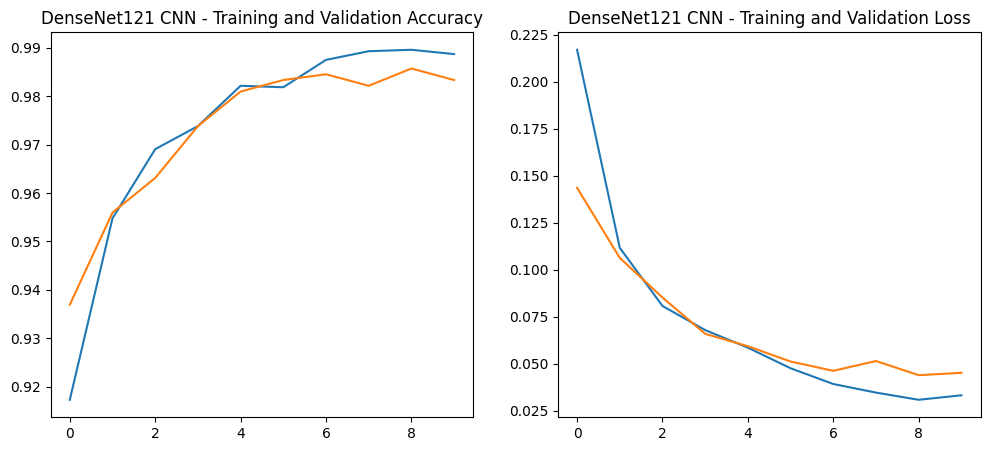


--- ResNet50V2 ---
ResNet50V2 Model Summary:


Model: "ResNet50V2_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,827,201 (90.89 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

Starting ResNet50V2 Training...
Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 84s 653ms/step - accuracy: 0.8900 - loss: 0.3146 - val_accuracy: 0.9488 - val_loss: 0.1362
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - accuracy: 0.9594 - loss: 0.1207 - val_accuracy: 0.9679 - val_loss: 0.0874
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.9768 - loss: 0.0771 - val_accuracy: 0.9679 - val_loss: 0.0875
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.9762 - loss: 0.0671 - val_accuracy: 0.9774 - val_loss: 0.0699
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - accuracy: 0.9852 - loss: 0.0464 - val_accuracy: 0.9738 - val_loss: 0.0721
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - accuracy: 0.9888 - loss: 0.0391 - val_accuracy: 0.9750 - val_loss: 0.0633
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.9840 - loss: 0.0390 - val_accuracy: 0.9738 - val_loss: 0.0591
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - accurac

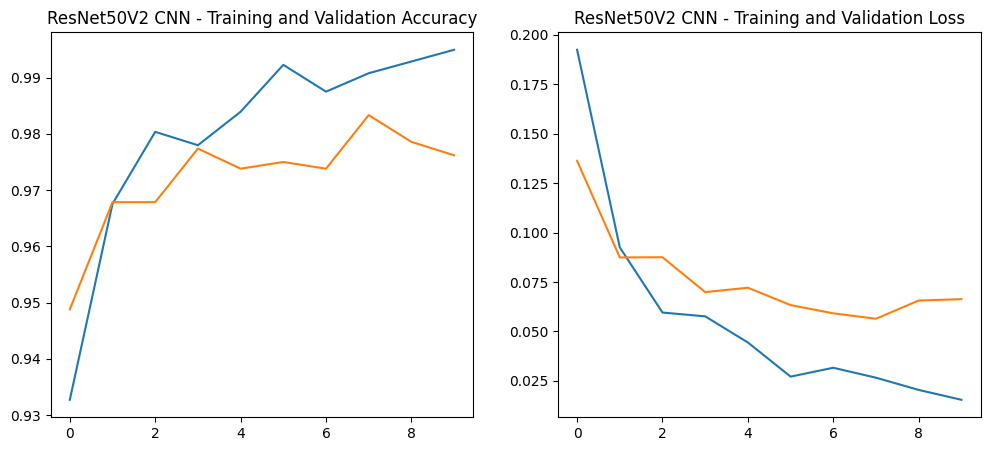


--- All Individual Models Trained for Ensemble ---


In [ ]:
trained_models = []
validation_sets = []

print("SECTION A: Training Individual Models for Ensemble")

# MobileNetV2
print("\n--- MobileNetV2 ---")
mnet_train_ds = create_preprocessed_dataset(raw_train_ds, mnet_preprocess, augment=True)
mnet_val_ds = create_preprocessed_dataset(raw_val_ds, mnet_preprocess, augment=False)
mnet_model = create_model(MobileNetV2, "MobileNetV2_Classifier", IMAGE_SIZE + (3,))
print("MobileNetV2 Model Summary:")
mnet_model.summary()
print("Starting MobileNetV2 Training...")
mnet_history = mnet_model.fit(
    mnet_train_ds,
    epochs=EPOCHS,
    validation_data=mnet_val_ds,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
)
evaluate_and_plot_individual(mnet_model, mnet_val_ds, class_names, "MobileNetV2 CNN", mnet_history)
trained_models.append(mnet_model)
validation_sets.append(mnet_val_ds)

# DenseNet121
print("\n--- DenseNet121 ---")
dnet_train_ds = create_preprocessed_dataset(raw_train_ds, dnet_preprocess, augment=True)
dnet_val_ds = create_preprocessed_dataset(raw_val_ds, dnet_preprocess, augment=False)
dnet_model = create_model(DenseNet121, "DenseNet121_Classifier", IMAGE_SIZE + (3,))
print("DenseNet121 Model Summary:")
dnet_model.summary()
print("Starting DenseNet121 Training...")
dnet_history = dnet_model.fit(
    dnet_train_ds,
    epochs=EPOCHS,
    validation_data=dnet_val_ds,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
)
evaluate_and_plot_individual(dnet_model, dnet_val_ds, class_names, "DenseNet121 CNN", dnet_history)
trained_models.append(dnet_model)
validation_sets.append(dnet_val_ds)

# ResNet50V2
print("\n--- ResNet50V2 ---")
resnet_train_ds = create_preprocessed_dataset(raw_train_ds, resnet_preprocess, augment=True)
resnet_val_ds = create_preprocessed_dataset(raw_val_ds, resnet_preprocess, augment=False)
resnet_model = create_model(ResNet50V2, "ResNet50V2_Classifier", IMAGE_SIZE + (3,))
print("ResNet50V2 Model Summary:")
resnet_model.summary()
print("Starting ResNet50V2 Training...")
resnet_history = resnet_model.fit(
    resnet_train_ds,
    epochs=EPOCHS,
    validation_data=resnet_val_ds,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
)
evaluate_and_plot_individual(resnet_model, resnet_val_ds, class_names, "ResNet50V2 CNN", resnet_history)
trained_models.append(resnet_model)
validation_sets.append(resnet_val_ds)

print("\n--- All Individual Models Trained for Ensemble ---")


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
print("SECTION B: Ensemble Model Evaluation")
# 1. Get true labels from one validation set
# (All validation sets have the same images and labels)
print("Extracting true labels from validation set...")
y_true_list = []

# We only need to iterate over one of the validation sets (e.g., validation_sets[0])
for images, labels in validation_sets[0]:
    # Since label_mode='binary', labels are already 0 or 1, not one-hot
    y_true_list.extend(labels.numpy().flatten()) # Get class indices (0 or 1)

y_true_classes = np.array(y_true_list)

# 2. Get predictions (probabilities) from all trained models
all_predictions_list = []
for model, val_ds in zip(trained_models, validation_sets):
    print(f"Generating predictions from {model.name}...")
    # Model.predict will return probabilities (N, 1) for sigmoid output
    preds = model.predict(val_ds).flatten() # Flatten to (N,) for consistency
    all_predictions_list.append(preds)

# 3. Average the predictions (soft voting)
print("Averaging predictions for ensemble...")
# This averages the probabilities from all models
# Shape will be (num_samples,) after flattening
ensemble_predictions = np.mean(all_predictions_list, axis=0)

# 4. Calculate metrics from the averaged ensemble predictions
# Get the final predicted class from the sigmoid-like (N,) output
# We use a 0.5 threshold to decide the class
ensemble_pred_classes = (ensemble_predictions > 0.5).astype(int)

# Now, we can define the variables that were missing
ensemble_acc = accuracy_score(y_true_classes, ensemble_pred_classes)

# Calculate ROC-AUC
num_classes = len(class_names) # Assuming 'class_names' is defined
if num_classes == 2:
    # For binary classification, use the probability of the positive class
    # which is the direct output of the sigmoid
    ensemble_roc_auc = roc_auc_score(y_true_classes, ensemble_predictions)
else:
    # This block won't be reached given label_mode='binary'
    pass

print("\n  FINAL PERFORMANCE SUMMARY: Ensemble")
print(f"ENSEMBLE (MNetV2 + DNet121 + RNet50V2) Accuracy: {ensemble_acc * 100:.2f}%")
print(f"ENSEMBLE ROC-AUC: {ensemble_roc_auc:.4f}")


SECTION B: Ensemble Model Evaluation
Extracting true labels from validation set...
Generating predictions from MobileNetV2_Classifier...
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
Generating predictions from DenseNet121_Classifier...
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step
Generating predictions from ResNet50V2_Classifier...
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step
Averaging predictions for ensemble...

  FINAL PERFORMANCE SUMMARY: Ensemble
ENSEMBLE (MNetV2 + DNet121 + RNet50V2) Accuracy: 84.76%
ENSEMBLE ROC-AUC: 0.8044


SAVING THE MODEL TO THE DRIVE:

In [ ]:
print("SECTION C: Saving Models to Google Drive")
MODEL_SAVE_DIR = os.path.join("/content/drive/My Drive/PROJECTS", "Tuberculosis_Trained_Pure_Ensemble")
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
# Save the weights of all three models
for model in trained_models:
    # Use the corrected '.weights.h5' extension
    save_path = os.path.join(MODEL_SAVE_DIR, f'{model.name}_weights.weights.h5')
    model.save_weights(save_path)
    print(f"Saved {model.name} weights to: {save_path}")
print("\n--- Process Finished. Weights are saved in your Google Drive. ---")

SECTION C: Saving Models to Google Drive
Saved MobileNetV2_Classifier weights to: /content/drive/My Drive/PROJECTS/Tuberculosis_Trained_Pure_Ensemble/MobileNetV2_Classifier_weights.weights.h5
Saved DenseNet121_Classifier weights to: /content/drive/My Drive/PROJECTS/Tuberculosis_Trained_Pure_Ensemble/DenseNet121_Classifier_weights.weights.h5
Saved ResNet50V2_Classifier weights to: /content/drive/My Drive/PROJECTS/Tuberculosis_Trained_Pure_Ensemble/ResNet50V2_Classifier_weights.weights.h5

--- Process Finished. Weights are saved in your Google Drive. ---


THE TESTING OF THE MODEL:

In [ ]:
def predict_ensemble_image(models, preprocess_functions, image_size, labels):
    print("\n--- Please upload a single chest X-ray image for ensemble prediction: ---")
    try:
        uploaded = files.upload()
    except Exception as e:
        print(f"Error during file upload utility: {e}")
        print("Please ensure you are running this in a Colab notebook.")
        return
    if not uploaded:
        print("No file uploaded. Skipping single image prediction.")
        return
    file_name = next(iter(uploaded))
    try:
        # 1. Load the raw image once
        img = keras_image.load_img(file_name, target_size=image_size)
        img_array = keras_image.img_to_array(img)
        all_prediction_probs = []
        # 2. Loop through each model for prediction
        print(f"\nProcessing {file_name} through {len(models)} models...")
        for i, model in enumerate(models):
            preprocess_fn = preprocess_functions[i]
            # Apply model-specific preprocessing
            input_data = np.expand_dims(img_array, axis=0)
            processed_input = preprocess_fn(input_data)
            # Predict
            prob = model.predict(processed_input, verbose=0)[0][0]
            all_prediction_probs.append(prob)
            print(f" - {model.name} probability: {prob:.4f}")
        # 3. Ensemble step: Average the probabilities
        avg_prob = np.mean(all_prediction_probs)
        # 4. Determine final result
        if avg_prob >= 0.5:
            predicted_class_index = 1
            confidence_score = avg_prob
        else:
            predicted_class_index = 0
            confidence_score = 1.0 - avg_prob

        predicted_label = labels[predicted_class_index]
        # 5. Display Result
        print(f"🚀 ENSEMBLE Prediction for: {file_name}")
        print(f"Averaged Probability: {avg_prob:.4f}")
        print(f"Final Diagnosis: **{predicted_label.upper()}**")
        print(f"Confidence: {confidence_score * 100:.2f}%")
    except Exception as e:
        print(f"\nERROR during prediction for {file_name}: {e}")
        print("Please ensure the uploaded file is a valid image.")
    finally:
        if os.path.exists(file_name):
            os.remove(file_name)
# FINAL SECTION: Ensemble Image Prediction
print("SECTION C: Single Image Ensemble Prediction")
# Define the list of preprocessing functions used for your three models
PREPROCESS_FUNCTIONS = [mnet_preprocess, dnet_preprocess, resnet_preprocess]
# Execute the ensemble prediction function
# Note: 'trained_models' is populated in Section A
predict_ensemble_image(trained_models, PREPROCESS_FUNCTIONS, IMAGE_SIZE, class_names)
print("\n--- Full Process Finished. ---")

SECTION C: Single Image Ensemble Prediction

--- Please upload a single chest X-ray image for ensemble prediction: ---


Saving Tuberculosis-299.png to Tuberculosis-299.png

Processing Tuberculosis-299.png through 3 models...
 - MobileNetV2_Classifier probability: 0.9637
 - DenseNet121_Classifier probability: 0.9924
 - ResNet50V2_Classifier probability: 0.7996
🚀 ENSEMBLE Prediction for: Tuberculosis-299.png
Averaged Probability: 0.9186
Final Diagnosis: **TUBERCULOSIS**
Confidence: 91.86%

--- Full Process Finished. ---
